# ReGRID model analysis
### for assessing data center siting strategies

Note:
- This notebook depends on output files generated by the following notebooks:
  - model_DC.ipynb
  - analysis_system.ipynb
  - analysis_DClocation.ipynb

In [36]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as lines
import math
import os
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry import Polygon

In [37]:
# Model definition

TERM = '1y'
STEP = 6
VER = 'v7'
BOUNDARY = 'japan'
NUCLEAR_AVAILABILITY = 1
POTENTIAL_AVAILABILITY= 50
POTENTIAL_CASE = 'base'
COST_CASE = 'moderate'

In [38]:
dir = f"ReGRID2_{VER}_analysis_{TERM}_{STEP}_{BOUNDARY}_n{NUCLEAR_AVAILABILITY}_p{POTENTIAL_AVAILABILITY}_{POTENTIAL_CASE}_{COST_CASE}"
if not os.path.exists(dir):
    os.makedirs(f'output/{dir}', exist_ok=True)
print(dir)

def get_model_name(year, pathway, scenario, strategy):
    return f"ReGRID2_{VER}_{year}_{pathway}_{TERM}_{STEP}_{BOUNDARY}_n{NUCLEAR_AVAILABILITY}_p{POTENTIAL_AVAILABILITY}_{POTENTIAL_CASE}_{COST_CASE}_{scenario}_{strategy}"

ReGRID2_v7_analysis_1y_6_japan_n1_p50_base_moderate


In [39]:
# Data for analysis

# Region list
region_list = pd.read_csv('input/region.csv', index_col='code', dtype={'code':str, 'DSN':str})
REGION = region_list.index.to_list() # All nodes
SUBSTATION = pd.read_csv('input/region_substation.csv', index_col=0, dtype={'region':str})['region'].to_list() # Substation nodes
NODE = [r for r in REGION if r not in SUBSTATION] # Resource nodes
AREA = region_list['DSN'].copy() # Distribution area
REGION06 = pd.Series(data=[f"{r:>6}".replace(' ','_') for r in REGION], index=REGION) # Region list (6 digit code)
position = pd.read_csv('input/analysis/position.csv', index_col=0, dtype={'code':str}) # coordination

# Parameters
P = pd.read_csv(f'input/technology/technology_C1.csv', index_col=0)
P = P[(P['year'] == 2050) & (P['scenario'] == 'moderate')]

# Technology list
RESOURCE = ['hydro','geoth','river','onwin','of-fx','of-fl','solar']
WASTE = ['waste','msw-c']
WOODY = ['woody','beccs']
THERMAL = ['oil-p','coalp','coalc','gas-p','gas-c','nuclr']
STORAGE = ['stpmp','stbat']
H2TECH = ['st-h2','h2cmp','el-h2','h2-el']
DACCS = ['daccs']

# JPY -> USD
USD = 107 # TTM in 2020

In [ ]:
# Scenarios
PATHWAY = ['C7','C1']
STRATEGY = ['BAU','ILA','DEV']
YEAR = ['2020','2030','2040','2050']


# Data center electricity demand (TWh)
DC_demand_TWh = {
    "High":{'2020':20, '2030':36, '2040':105, '2050':211},
    "Mid":{'2020':20, '2030':36, '2040':65, '2050':107},
    "Low":{'2020':20, '2030':36, '2040':40, '2050':43},
}
DC_SCENARIO = list(DC_demand_TWh.keys())

# TWh -> GW
DC_CF = 0.8 # Capacity factor of data center from reference
DC_demand_GW = {
    key: {year: value / 8760 / DC_CF * 1000 for year, value in values.items()} for key, values in DC_demand_TWh.items()
}

In [41]:
# Chart setting

pathway_name = {'C1':'1.5°C','C3':'WB2°C','C7':'Baseline'}
strategy_name = {'BAU':'BAU', 'ILA':'ILA', 'DEV':'FLEX', 'NoDC':'NoDC'}

line_color = {'C1':'#46763B','C3':'#0082A3','C7':'#B77D43', 'BAU':'#B77D43','ILA':'#46763B','DEV':'#0082A3','NoDC':'#aaa'}
line_style = {'BAU':'-','ILA':'--','DEV':':','NoDC':'-'}

In [42]:
# Chart paramter
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['font.size'] = 7
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7
plt.rcParams['axes.linewidth'] = 0.5

MAX_WIDTH = 180 / 25.4 # inch in 180mm

In [43]:
# Modules for drawing square polygon map

def create_square_polygon(center, size, scale):
    # Create square polygon

    x, y = center
    length = math.sqrt(size * scale) / 110 # scale=1: Relative area
    half = length/2
    coordinates = [
        (x - half, y + half), # top-left
        (x - half, y - half), # bottom-left
        (x + half, y - half), # bottom-right
        (x + half, y + half), # top-right
        (x - half, y + half) # top-left
    ]
    
    return Polygon(coordinates)


def square_map(lng, lat, data, scale, area, title):
    # Draw polygon map

    square_polygon = [create_square_polygon((lng[reg], lat[reg]), data[reg], scale) for reg in REGION]

    coord = {"japan":[126.6, 147.0, 25.6, 45.9],
            "tokyo":[139.3, 140.9, 34.9, 36.4]}
    
    area_coord = coord[area]
    map_width = area_coord[1]-area_coord[0]
    map_height = area_coord[3]-area_coord[2]
    line_width = 0.05 if area == "japan" else 0.2

    plt.figure(figsize=(MAX_WIDTH*0.3, MAX_WIDTH*0.33), dpi=900)
    ax = plt.axes(projection=ccrs.PlateCarree())
    nation_shapes = list(shpreader.Reader("input/analysis/shp/Japan/Japan.shp").geometries())
    municipal_shapes = list(shpreader.Reader("input/analysis/shp/1741municipalities/1741municipalities.shp").geometries())
    ax.add_geometries(nation_shapes, ccrs.PlateCarree(), edgecolor=(0.1,0.1,0.1,1), facecolor=(0,0,0,0), linewidth = line_width)
    ax.add_geometries(municipal_shapes, ccrs.PlateCarree(), edgecolor=(0.1,0.1,0.1,0.3), facecolor=(0.9,0.9,0.9,0.0), linewidth = line_width*0.3)
    ax.add_geometries(square_polygon, ccrs.PlateCarree(), edgecolor=(0,0,0,0), facecolor=(0.6,0.2,0.6,0.35), linewidth = 0.0)
    ax.set_extent(area_coord, crs=ccrs.PlateCarree())

    # Legend
    legend_x = area_coord[0] + map_width * 0.75
    legend_y = area_coord[2] + map_height * 0.25
    legend_interval = map_height * 0.05
    legend_length = map_width * 0.04
    
    if area == "japan":
        ax.annotate("Capacity", xy=(legend_x, legend_y+legend_interval), size=5, verticalalignment='center', fontweight='bold')

    for n,land_area in enumerate([1000, 500, 100]):
        land_size = [create_square_polygon((legend_x+legend_length/2, legend_y-legend_interval*n), land_area, scale)]
        ax.add_geometries(land_size, ccrs.PlateCarree(), edgecolor=(0,0,0,0), facecolor=(0.6,0.2,0.6,0.35), linewidth = 0.0)
        ax.annotate("%s MW" % '{:,}'.format(land_area), xy=(legend_x+legend_length, legend_y-legend_interval*n), size=5, verticalalignment='center')

    # Gridline
    if area == "japan":
        gl = ax.gridlines(draw_labels=True, linewidth=0.1, color='gray', alpha=0.6, linestyle='--')
        gl.top_labels = True
        gl.right_labels = False
        gl.bottom_labels = False
        gl.left_labels = True
        gl.xlabel_style = {'fontsize': 5, 'color': "gray"}
        gl.ylabel_style = {'fontsize': 5, 'color': "gray"}
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        gl.xpadding = 1
        gl.ypadding = 1
    
    # Draw
    plt.axis('off')
    plt.savefig(f"output/{dir}/map_datacenter_{title}.jpg", bbox_inches='tight', pad_inches=0, transparent=False, dpi=900)
    plt.savefig(f"output/{dir}/map_datacenter_{title}.eps", bbox_inches='tight', pad_inches=0, transparent=False, dpi=900)
    plt.show()
    plt.clf()

In [ ]:
# Draw data center location

location_data = pd.DataFrame(columns=['pathway','scenario','strategy','year','value'])

for scenario in ['Mid']:
    for strategy in STRATEGY:
        for pathway in PATHWAY:
            for year in YEAR:
                location_scenario = pd.DataFrame(index=REGION, columns=['pathway','scenario','strategy','year','value'])
                model_name = get_model_name(year, pathway, scenario, strategy)
                location_scenario['value'] = pd.read_csv(f'output/{model_name}/datacenter_capacity_{year}.csv', index_col=0, dtype={'region':str})['value']
                location_scenario['pathway'] = pathway
                location_scenario['scenario'] = scenario
                location_scenario['strategy'] = strategy
                location_scenario['year'] = year
                location_scenario = location_scenario.fillna(0)
                location_data = pd.concat([location_data,location_scenario], axis=0)
                
                # square_map(position['long'], position['lat'], location_scenario['value'], 2, "japan", f"{scenario}_{strategy}_{scenario}_{year}")
                # square_map(position['long'], position['lat'], location_scenario['value'], 0.04, "tokyo", f"{scenario}_{strategy}_{scenario}_{year}_tokyo")

# Export
# location_data.reset_index().pivot(index=['index','scenario', 'scenario', 'strategy'], columns='year', values='value').to_csv(f"output/{dir}/DC_location_{scenario}.csv")

In [45]:
# Additional sytem cost

def calc_addtitional_cost(pathway, scenario, strategy, year):
    try:
        wDC_result = get_model_name(year, pathway, scenario, strategy)
        system_cost_wDC = pd.read_csv(f'output/{wDC_result}/cost_total_{wDC_result}.csv', index_col=0)['0']['system_cost']

        woDC_result = get_model_name(year, pathway, 'NoDC', 'NoDC')
        system_cost_woDC = pd.read_csv(f'output/{woDC_result}/cost_total_{woDC_result}.csv', index_col=0)['0']['system_cost']
    
        return (system_cost_wDC - system_cost_woDC) / USD * 1000 # trillion JPY -> billion USD
    except:
        return np.NaN


def calc_system_cost(pathway, scenario, strategy, year):
    try:
        model_name = get_model_name(year, pathway, scenario, strategy)
        unit_system_cost_wDC = pd.read_csv(f'output/{model_name}/cost_total_{model_name}.csv', index_col=0)['0']['unit_cost']
    
        return unit_system_cost_wDC / USD * 1000 # trillion JPY -> billion USD
    except:
        return np.NaN
    

system_cost = pd.DataFrame(columns=['pathway','year','scenario','strategy','unit_system_cost','additional_cost'])
for pathway in PATHWAY:
    for scenario in DC_SCENARIO+['NoDC']:
        for strategy in STRATEGY+['NoDC']:
            for year in YEAR:
                system_cost.loc[len(system_cost)] = {'pathway':pathway, 
                                'year':year, 
                                'scenario':scenario, 
                                'strategy':strategy,
                                'unit_system_cost':calc_system_cost(pathway, scenario, strategy, year),
                                'additional_cost':calc_addtitional_cost(pathway, scenario, strategy, year)}

system_cost = system_cost.dropna(subset=['unit_system_cost'])

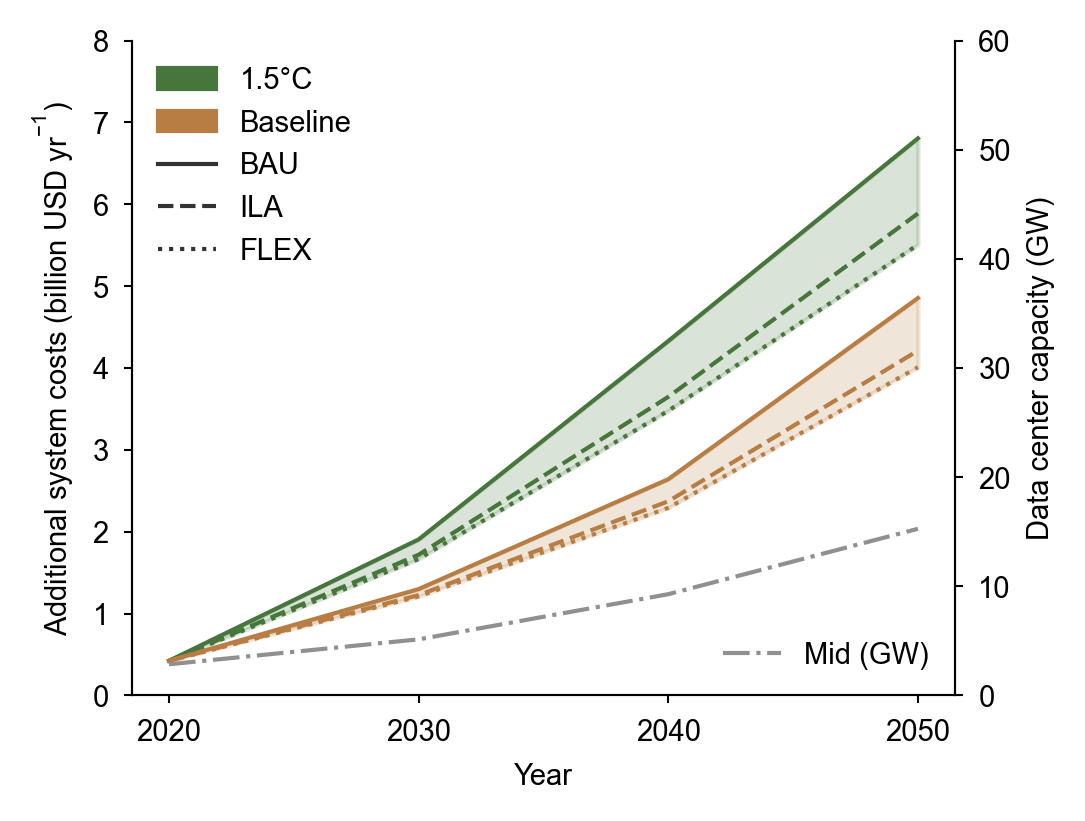

In [46]:
# Additional sytem cost
   
scenario = 'Mid'
DC_cost = system_cost[system_cost['scenario'] == scenario]

plt.figure(figsize=(MAX_WIDTH*0.5, MAX_WIDTH*0.5*0.8), dpi=300)

for (pathway, strategy), data in DC_cost.groupby(['pathway', 'strategy']):
    if strategy != 'NoDC':
        plt.plot(data['year'], data['additional_cost'],
                color=line_color[pathway], 
                linestyle=line_style[strategy],
                linewidth=1)
    
for pathway in PATHWAY:
    plt.fill_between(data['year'],
                    DC_cost[(DC_cost['pathway']==pathway) & (DC_cost['strategy']=='BAU')]['additional_cost'],
                    DC_cost[(DC_cost['pathway']==pathway) & (DC_cost['strategy']=='DEV')]['additional_cost'],
                    color=line_color[pathway], alpha=0.2)
    
# Legend
for pathway in PATHWAY:
    plt.fill_between([0,0], [0,0], [0,0],
                    label=pathway_name[pathway], color=line_color[pathway])
for line_key, line_val in line_style.items():
    if line_key != 'NoDC':
        plt.plot([0,0], [0,0], color="#333", linestyle=line_val, label=strategy_name[line_key], linewidth=1)
    
# Parameters
plt.ylim(0,8)
plt.ylabel('Additional system costs (billion USD yr$^{-1}$)')
plt.xlabel('Year')
plt.legend(loc='upper left', handlelength=2, frameon=False)
plt.gca().spines['top'].set_visible(False)

# Twin plot
ax2 = plt.gca().twinx()
ax2.plot(DC_demand_GW[scenario].keys(), DC_demand_GW[scenario].values(), label=f"{scenario} (GW)", color="#909090", linestyle="-.", linewidth=1)
ax2.set_ylim(0,60)
ax2.set_ylabel('Data center capacity (GW)')
ax2.spines['top'].set_visible(False)
plt.legend(loc='lower right', frameon=False)

# Draw
plt.savefig(f"output/{dir}/DC_cost_{scenario}.jpg", bbox_inches='tight', pad_inches=0, transparent=False, dpi=300)
plt.show()

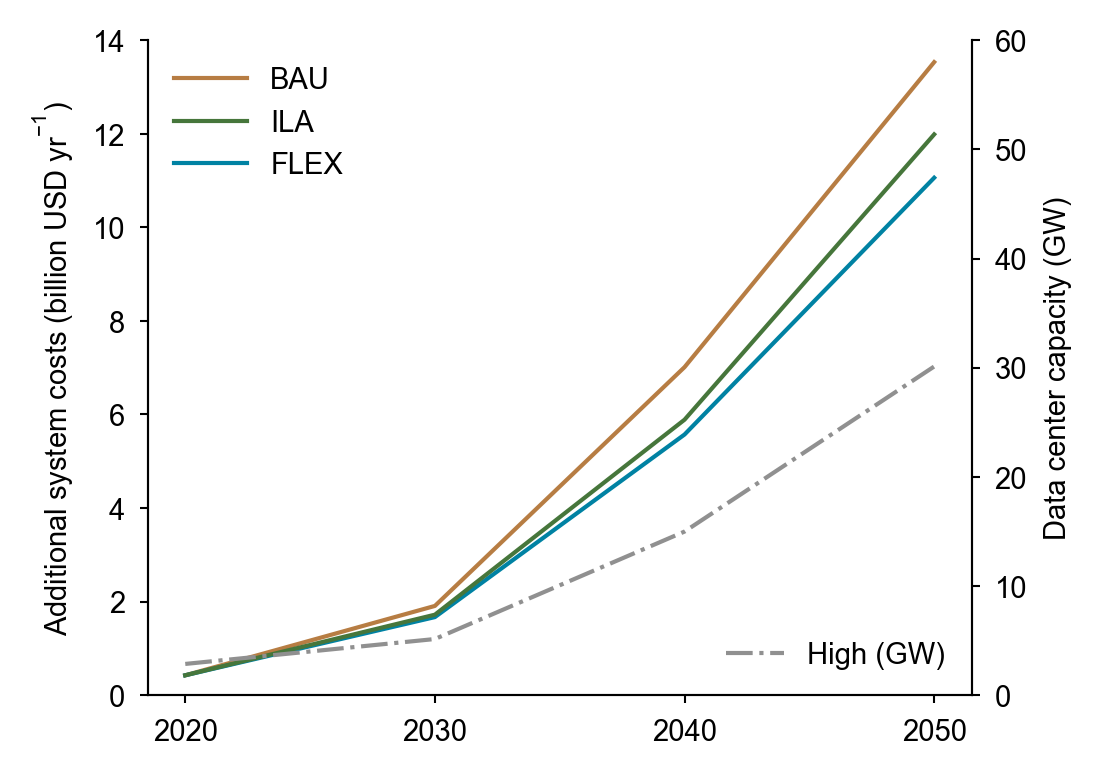

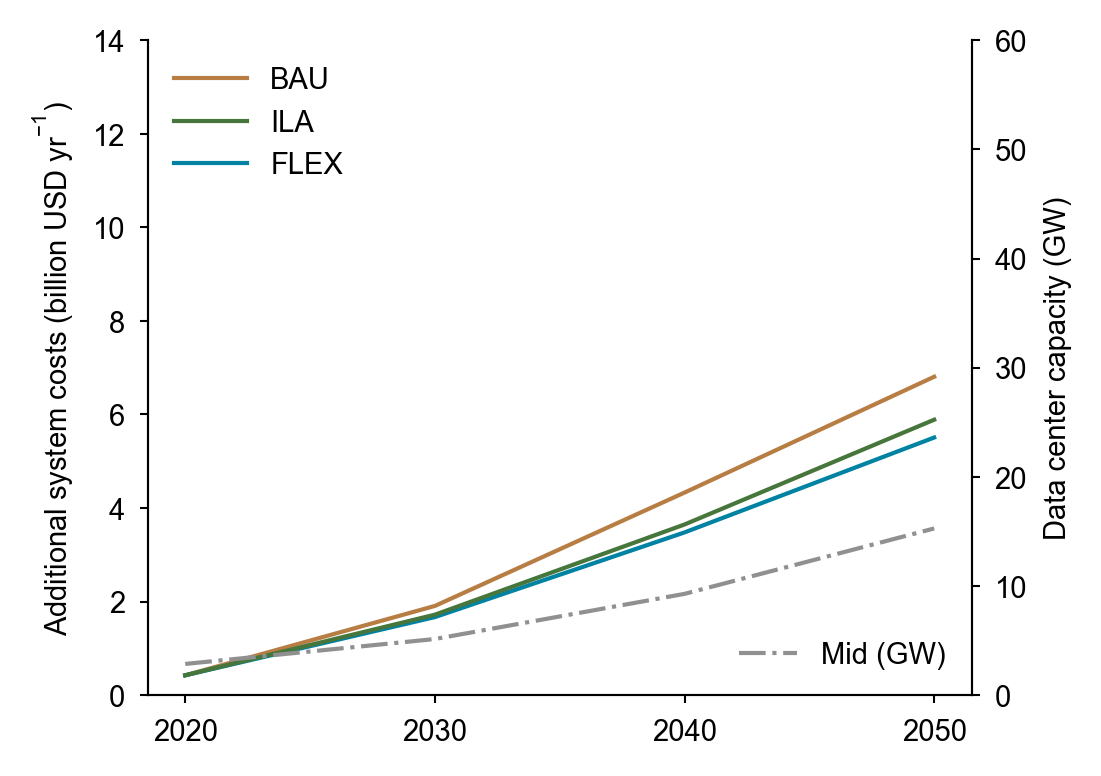

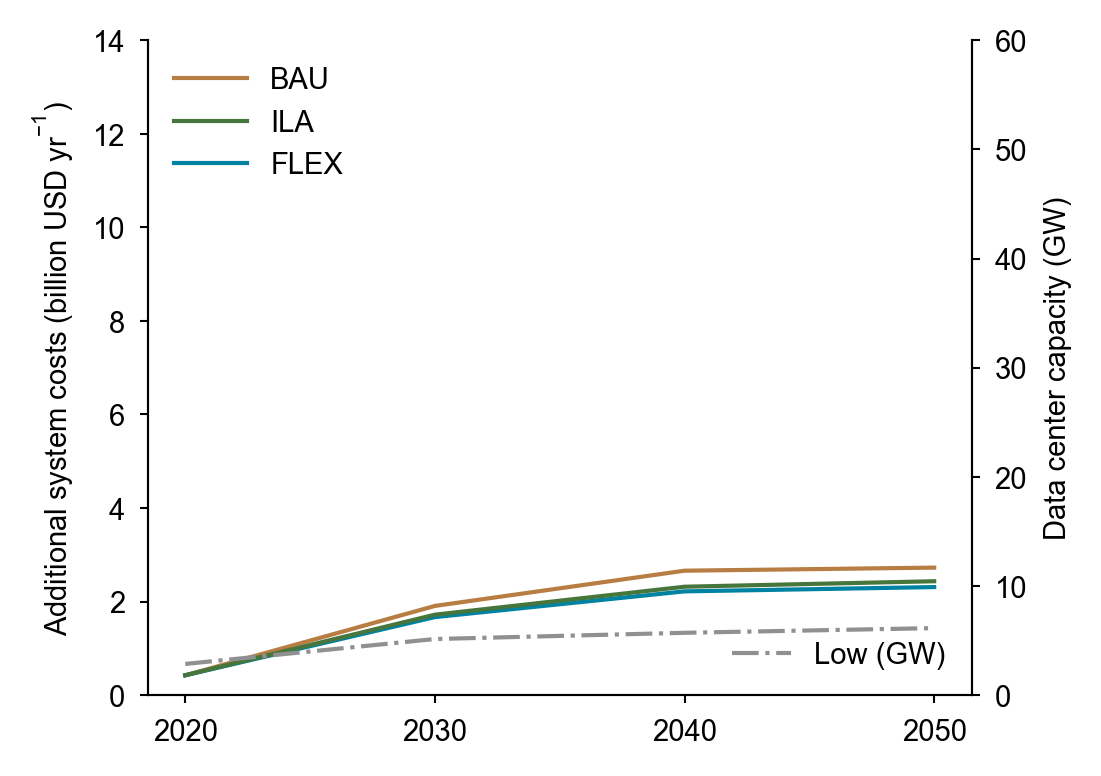

In [47]:
# Additional system cost

pathway = 'C1'
for scenario in DC_SCENARIO:
    
    DC_cost = system_cost[(system_cost['pathway'] == pathway) & (system_cost['scenario'] == scenario)]            

    plt.figure(figsize=(MAX_WIDTH*0.5, MAX_WIDTH*0.5*0.8), dpi=300)

    for (scenario, strategy), data in DC_cost.groupby(['scenario', 'strategy']):
        plt.plot(data['year'], data['additional_cost'], 
                color=line_color[strategy], 
                linestyle='solid',
                linewidth=1)
        
    # Legend
    for strategy in STRATEGY:
        plt.plot([0,0], [0,0], color=line_color[strategy], linestyle='solid', label=strategy_name[strategy], linewidth=1)
        
    # Parameters
    plt.ylim(0,14)
    plt.ylabel('Additional system costs (billion USD yr$^{-1}$)')
    plt.legend(loc='upper left', handlelength=2.5, frameon=False)
    plt.gca().spines['top'].set_visible(False)

    # Twin plot
    ax2 = plt.gca().twinx()
    ax2.plot(DC_demand_GW[scenario].keys(), DC_demand_GW[scenario].values(), label=f"{scenario} (GW)", color="#909090", linestyle="-.", linewidth=1)
    ax2.set_ylim(0,60)
    ax2.set_ylabel('Data center capacity (GW)')
    ax2.spines['top'].set_visible(False)
    plt.legend(loc='lower right', frameon=False)

    # Draw
    plt.savefig(f"output/{dir}/DC_cost_{scenario}_C1.jpg", bbox_inches='tight', pad_inches=0, transparent=False, dpi=300)
    plt.show()

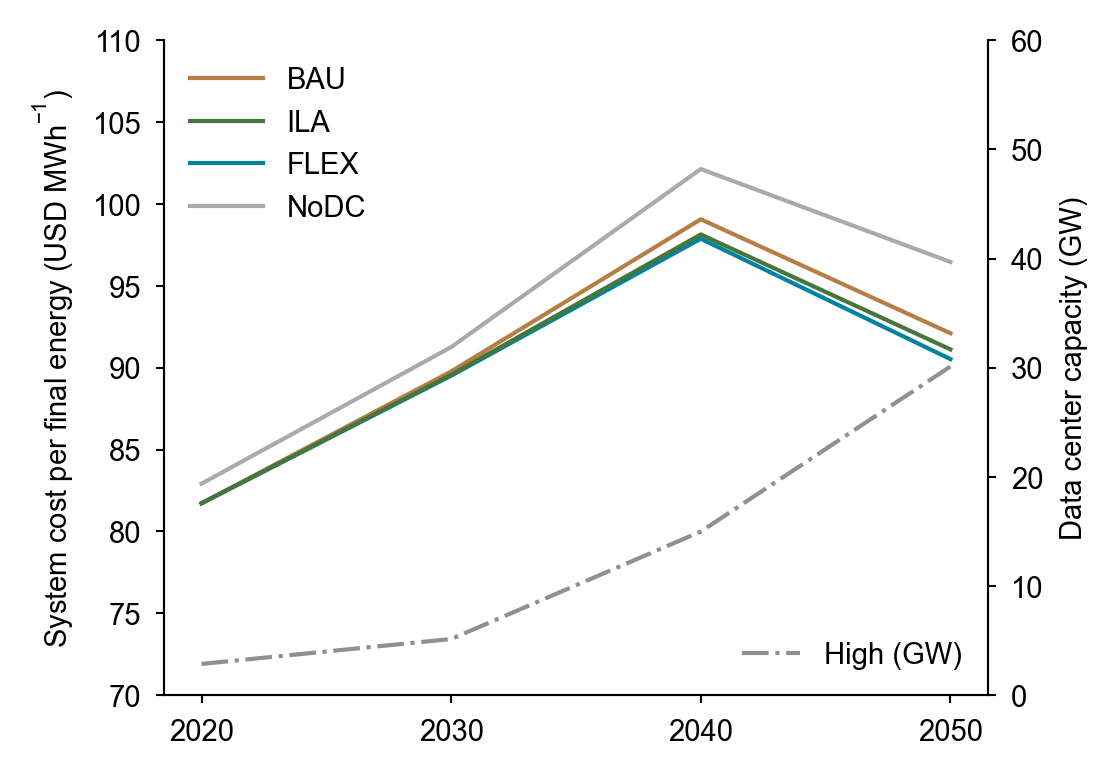

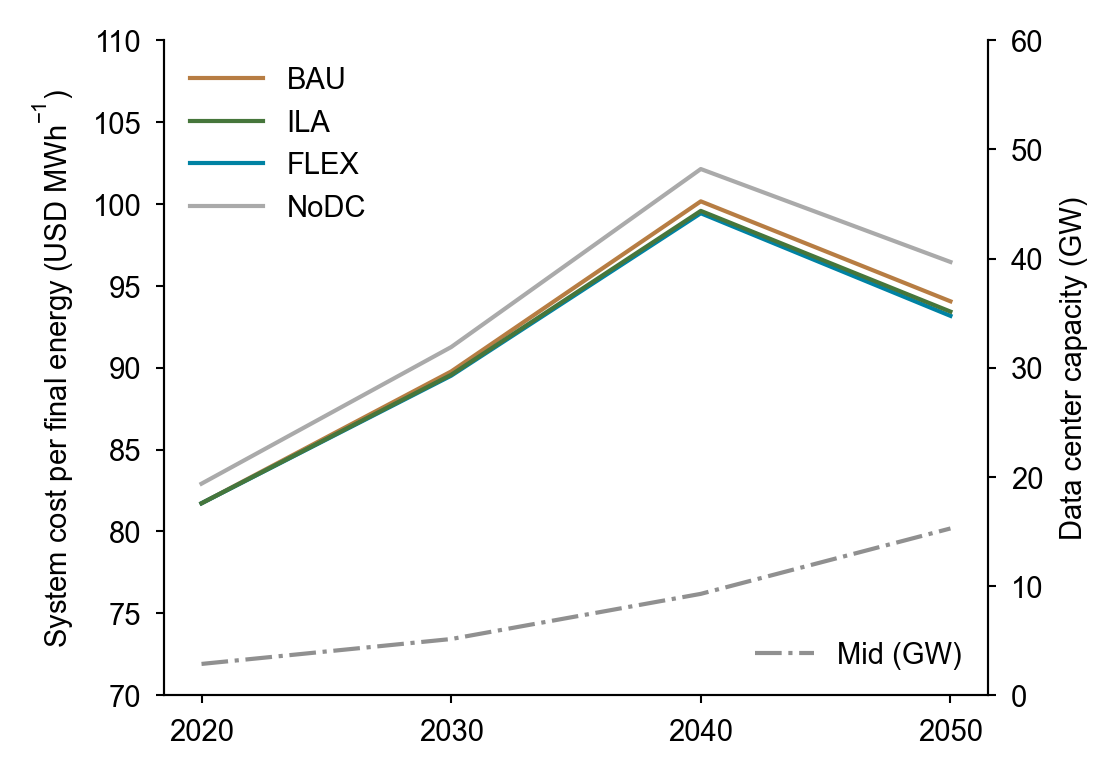

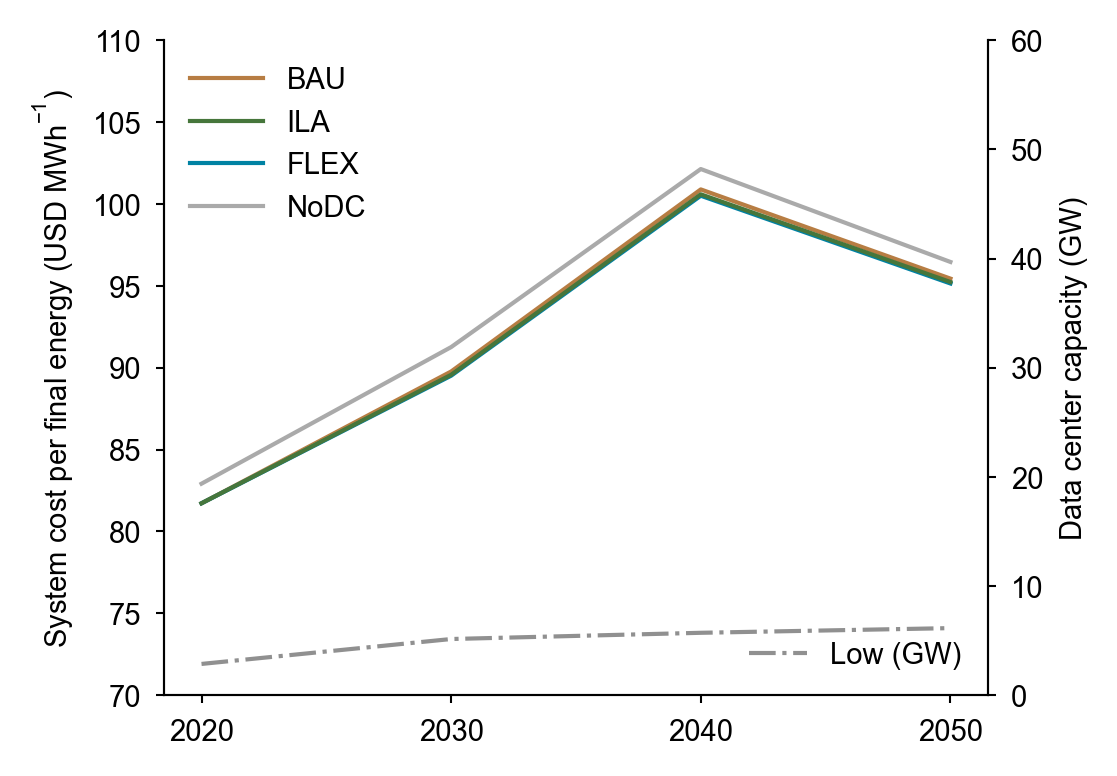

In [58]:
# System cost per final energy

for scenario in DC_SCENARIO:
    for pathway in ['C1']:
        
        DC_cost = system_cost[((system_cost['pathway'] == pathway) & ((system_cost['scenario'] == scenario) | (system_cost['scenario'] == 'NoDC')))]
                
        plt.figure(figsize=(MAX_WIDTH*0.5, MAX_WIDTH*0.5*0.8), dpi=300)

        for (pathway, strategy), data in DC_cost.groupby(['pathway', 'strategy']):
            plt.plot(data['year'], data['unit_system_cost'], 
                    color=line_color[strategy], 
                    linestyle='solid',
                    linewidth=1)
            
        # Legend
        for strategy in STRATEGY+['NoDC']:
            plt.plot([0,0], [0,0], color=line_color[strategy], linestyle='solid', label=strategy_name[strategy], linewidth=1)
            
        # Parameters
        plt.ylim(70,110)
        plt.ylabel('System cost per final energy (USD MWh$^{-1}$)')
        plt.legend(loc='upper left', handlelength=2.5, frameon=False)
        plt.gca().spines['top'].set_visible(False)

        # Twin plot
        ax2 = plt.gca().twinx()
        ax2.plot(DC_demand_GW[scenario].keys(), DC_demand_GW[scenario].values(), label=f"{scenario} (GW)", color="#909090", linestyle="-.", linewidth=1)
        ax2.set_ylim(0,60)
        ax2.set_ylabel('Data center capacity (GW)')
        ax2.spines['top'].set_visible(False)
        plt.legend(loc='lower right', frameon=False)

        # Draw
        plt.savefig(f"output/{dir}/unit_system_cost_{scenario}_C1.jpg", bbox_inches='tight', pad_inches=0, transparent=False, dpi=500)
        plt.show()

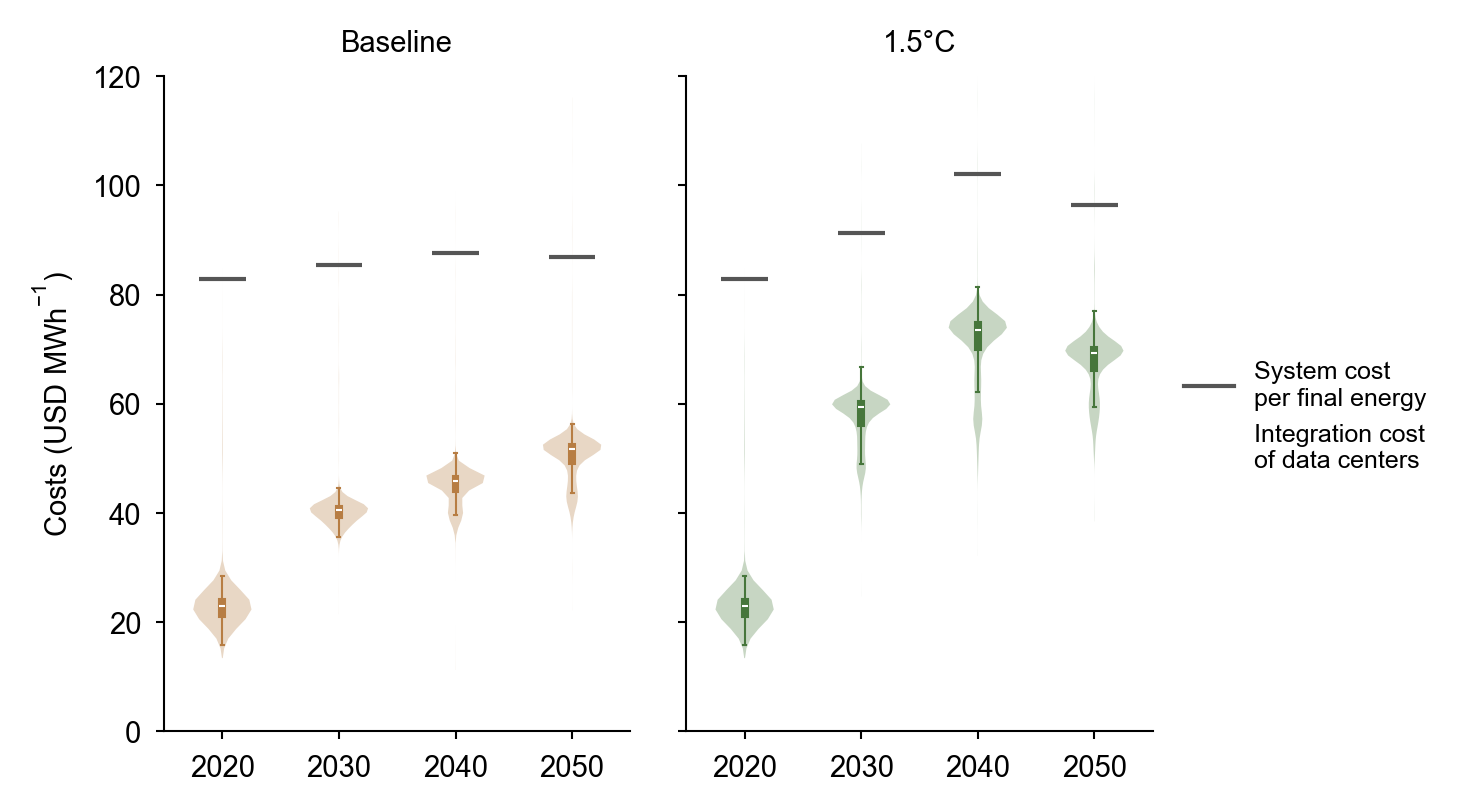

In [57]:
# Box plot

line_color_alpha = {'C1':'#C7D6C3','C7':'#E8D7C5'}

fig, axes = plt.subplots(1, len(PATHWAY), gridspec_kw={'wspace':0.12}, figsize=[MAX_WIDTH*0.6,MAX_WIDTH*0.5*0.8], dpi=300, sharey=True)
    
for i, scenario in enumerate(PATHWAY):
    df_mrc_year = pd.DataFrame()
    df_system_cost = pd.DataFrame(index=YEAR, columns=PATHWAY)
    box_color = line_color[scenario]

    for year in YEAR:
        prev_result = f"ReGRID2_{VER}_{year}_{scenario}_{TERM}_{STEP}_{BOUNDARY}_n{NUCLEAR_AVAILABILITY}_p{POTENTIAL_AVAILABILITY}_{POTENTIAL_CASE}_{COST_CASE}_NoDC_NoDC"
        if os.path.isfile(f'output/{prev_result}/mrc_{prev_result}.csv'):
            df_mrc_year[year] = pd.read_csv(f'output/{prev_result}/mrc_{prev_result}.csv', index_col=0)['unit_cost']
            df_system_cost[scenario][year] = pd.read_csv(f'output/{prev_result}/cost_total_{prev_result}.csv', index_col=0)['0']['unit_cost'] / USD * 1000 #JPY/kWh -> USD/MWh
        else:
            print("No data:", prev_result)

    # Integration cost
    axes[i].boxplot(df_mrc_year, positions=[2020,2030,2040,2050], widths=0.5, patch_artist=True,
                boxprops=dict(facecolor=box_color, color=box_color, linewidth=0.5),
                whiskerprops=dict(color=box_color, linewidth=0.5),
                capprops=dict(color=box_color, linewidth=0.5),
                medianprops=dict(color='#fff', linewidth=0.5),
                flierprops=dict(marker='o', markersize=0))
    violin = axes[i].violinplot(df_mrc_year, positions=[2020,2030,2040,2050], widths=5, bw_method="scott", showmeans=False, showextrema=False, showmedians=False)

    for body in violin['bodies']:
        body.set_color(line_color_alpha[scenario])
        body.set_edgecolor("none")
        body.set_alpha(1)

    # System cost
    threshbold = df_system_cost[scenario].to_list()
    for n, y in enumerate(threshbold, start=1):
        axes[i].hlines(y=y, xmin=n*10+2008, xmax=n*10+2012, color='#555', linestyle='-', linewidth=1)

    axes[i].set_title(pathway_name[scenario], fontsize=7)
    axes[i].set_ylim(0, 120)
    axes[i].set_xlim(2015, 2055)
    axes[i].set_xticks([2020,2030,2040,2050])
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

axes[0].set_ylabel('Costs (USD MWh$^{-1}$)')

violin_handle = patches.Patch(color='#fff', linewidth=0, label="Integration cost \nof data centers")
threshold_handle = lines.Line2D([], [], color='#555', linestyle='-', linewidth=1, label="System cost \nper final energy")
axes[1].legend(handles=[threshold_handle, violin_handle], loc='upper left', fontsize=6, frameon=False, bbox_to_anchor=(1.02, 0.6))

plt.savefig("output/%s/integration_cost_variation.jpg" % (dir), bbox_inches='tight', pad_inches=0, transparent=False, dpi=300)
plt.savefig("output/%s/integration_cost_variation.eps" % (dir), bbox_inches='tight', pad_inches=0, dpi=300)
plt.show()

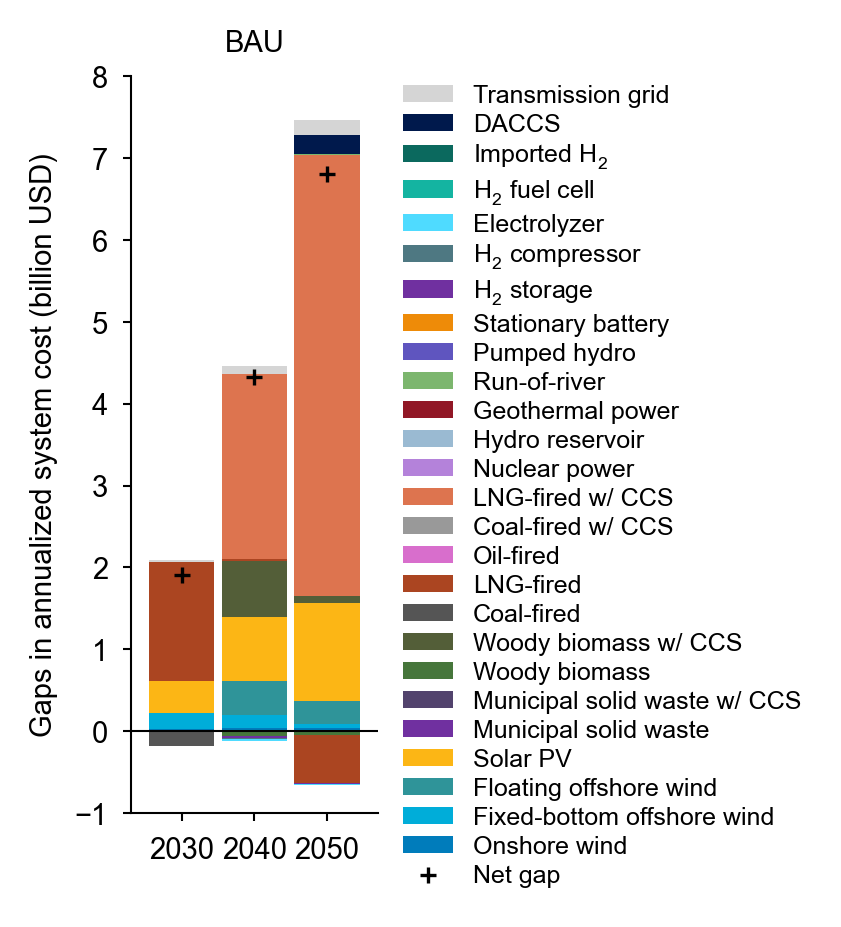

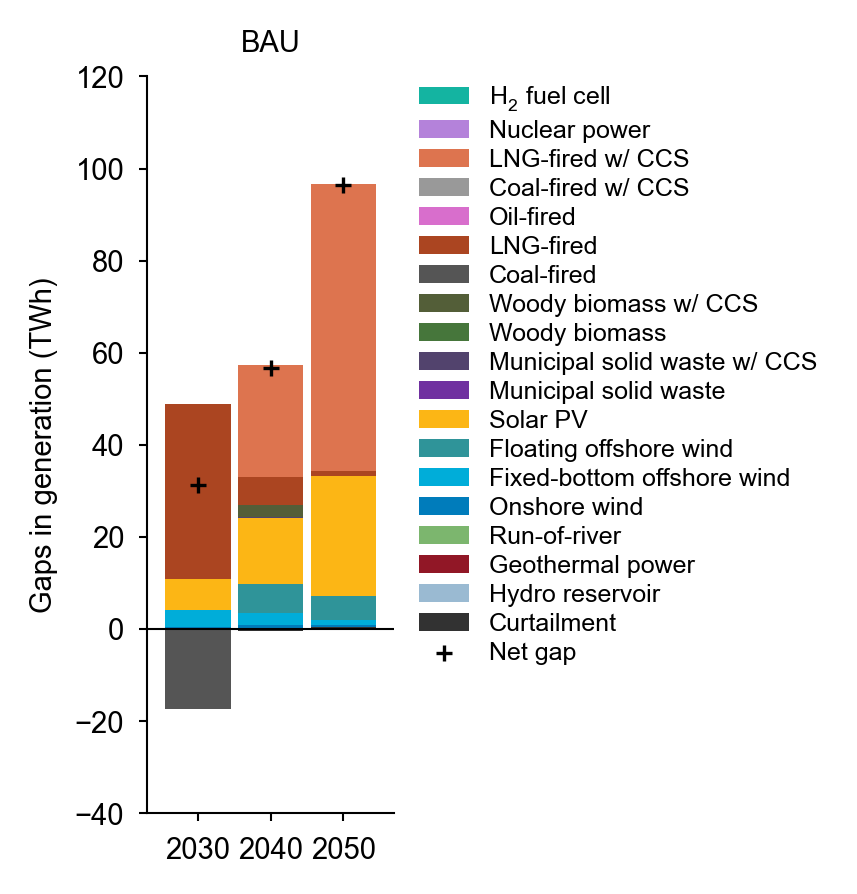

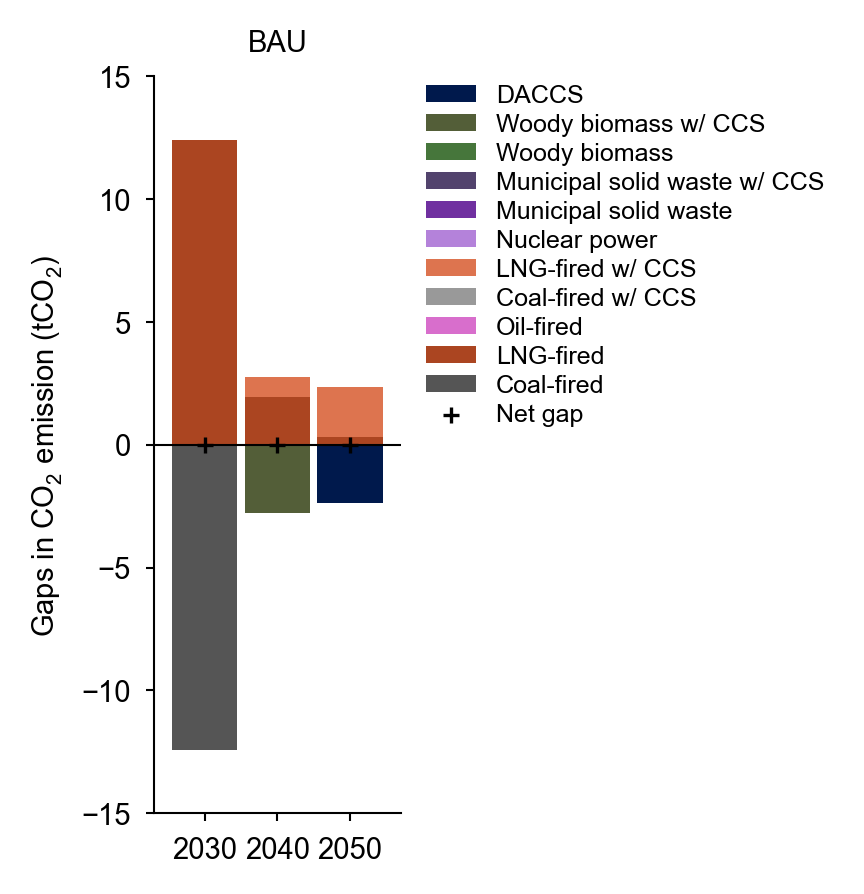

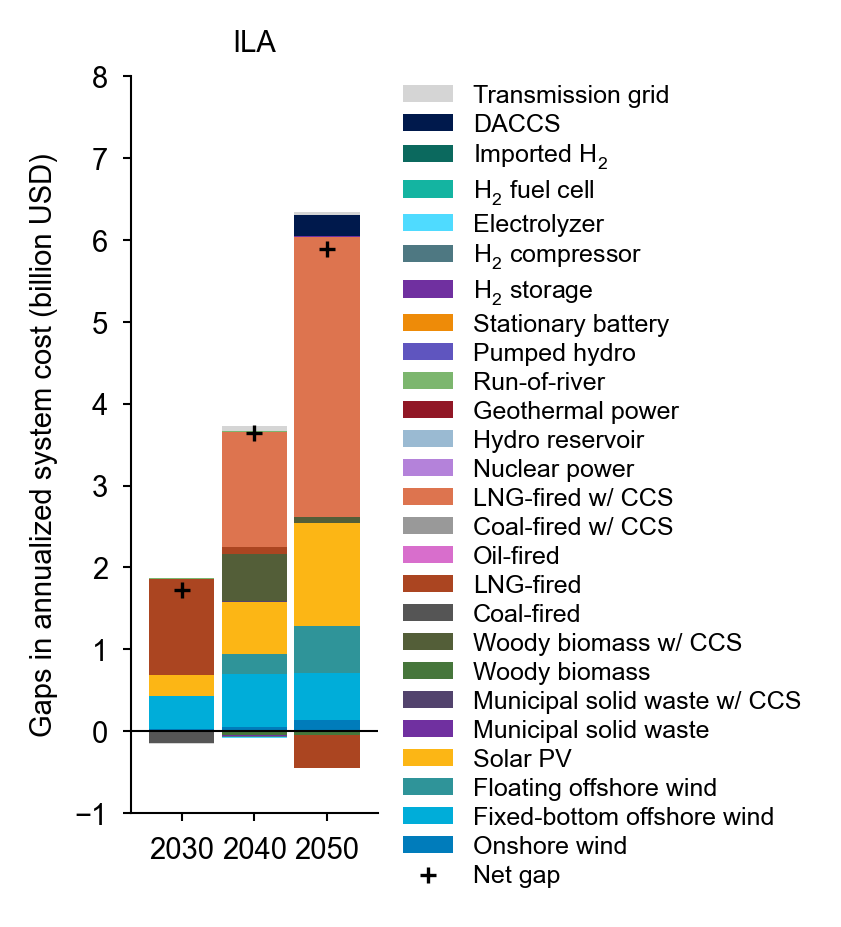

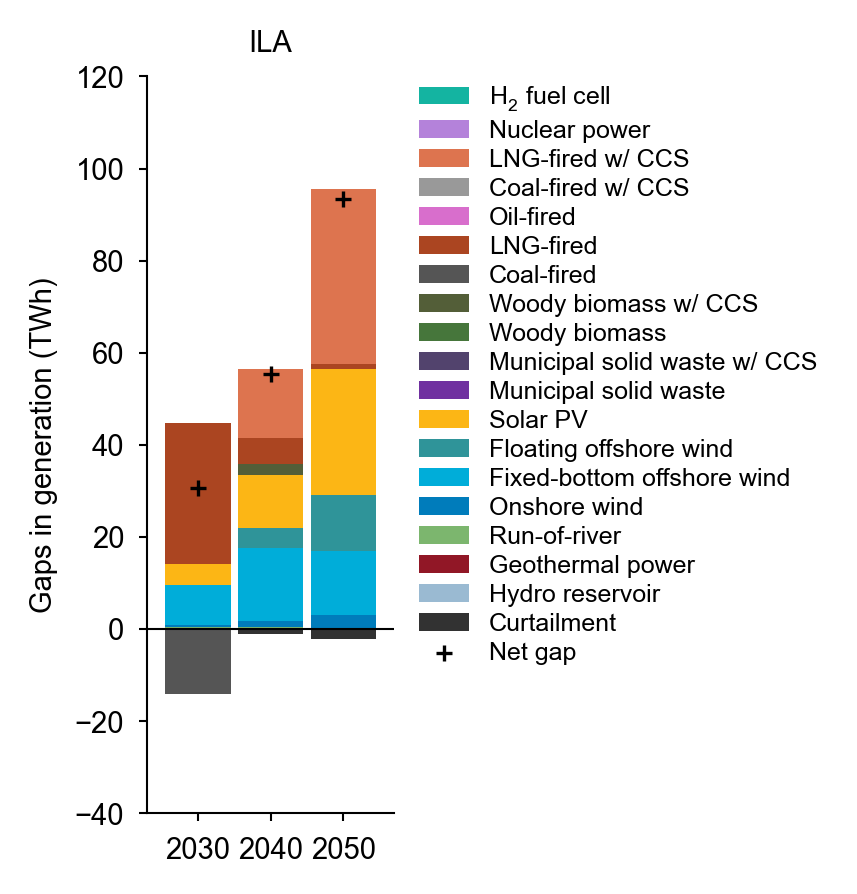

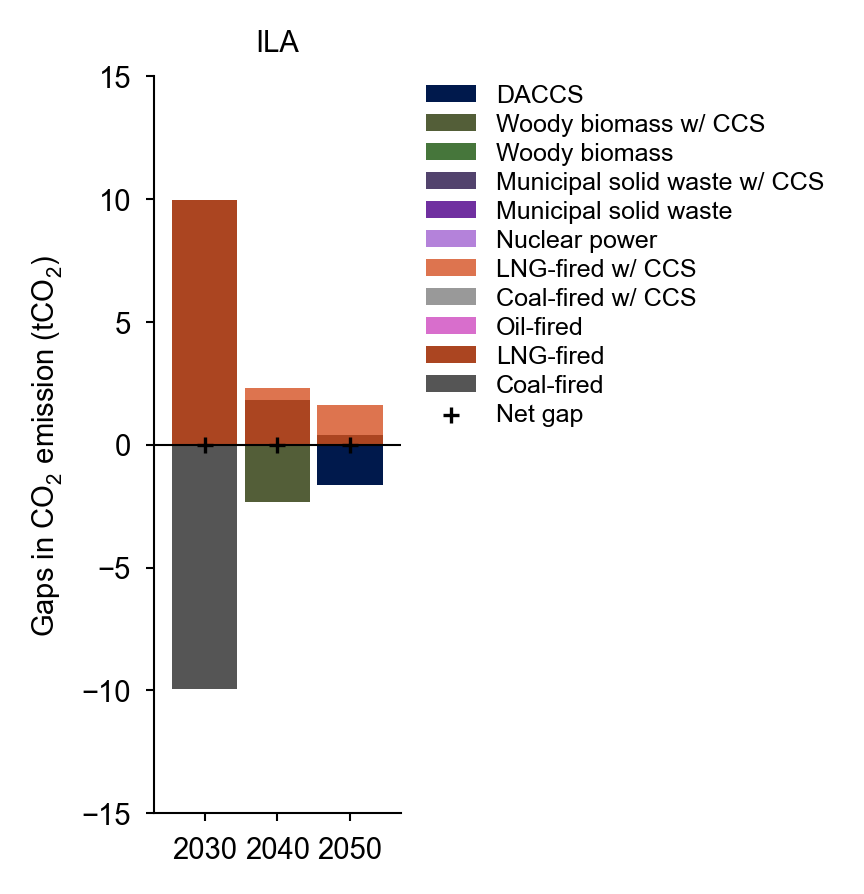

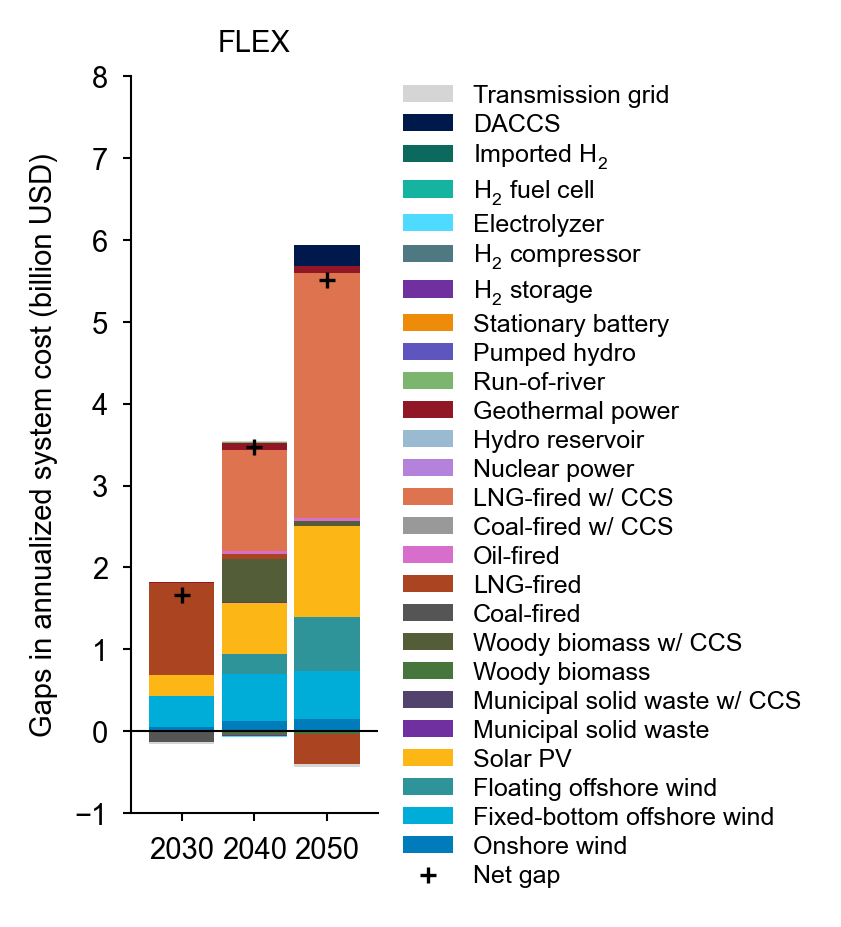

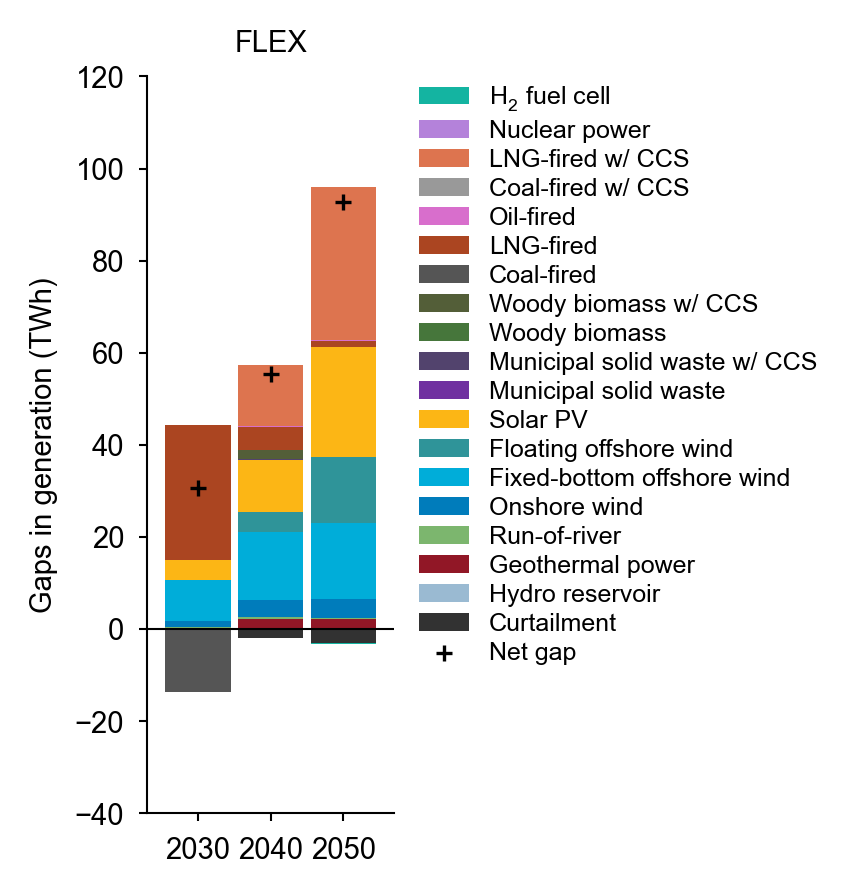

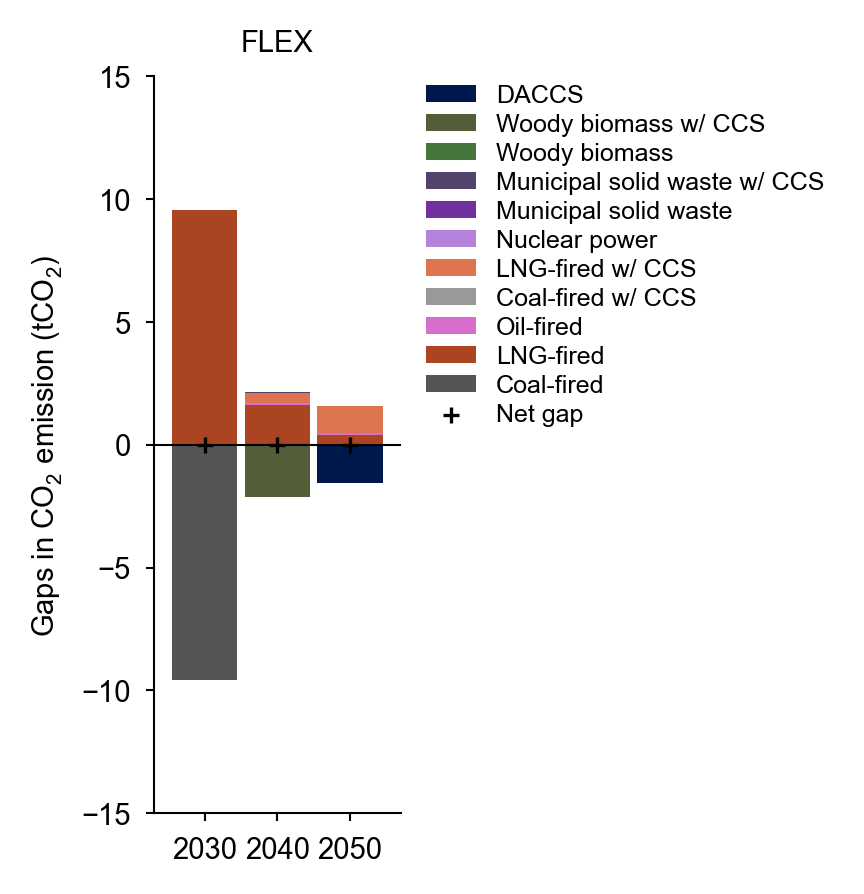

In [50]:
# Transition gap

def transition_data(param, pathway, scenario, strategy):
    data = pd.DataFrame()
    for year in ['2030','2040','2050']:
        model_name = get_model_name(year, pathway, scenario, strategy)
        data[year] = pd.read_csv(f'output/{model_name}/{param}_{model_name}.csv', index_col=0)
    return data


def transition_gap(param, pathway ,scenario, loc0, loc1):
    data0 = transition_data(param, pathway, scenario, loc0)
    data1 = transition_data(param, pathway, 'NoDC', loc1)
    return data0 - data1


def transition_gap_plot(data, label, title, ymin, ymax, file_name, legend_size):
    fig, ax = plt.subplots(1, 1, gridspec_kw={'wspace':0.04}, figsize=[MAX_WIDTH*0.15,MAX_WIDTH*0.45], dpi=300)

    # Stack plot
    data.plot(kind='bar', stacked=True, ax=ax, color=[P['color'][abr] for abr in data.columns], legend=None, linewidth=0, width=0.9)
    ax.tick_params(bottom=False, axis='y')
    ax.tick_params(axis='x', rotation=0)
    ax.set_ylabel(label)
    ax.set_xlabel("", fontsize=0)
    ax.set_ylim(ymin, ymax)
    ax.set_title(title, fontsize=7)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Net value point
    net_values = data.sum(axis=1)
    x_positions = ax.get_xticks()
    net_handle = ax.scatter(x_positions, net_values, color='black', marker="+", linewidths=0.8, s=15, zorder=5)

    # Legend
    handles, labels = ax.get_legend_handles_labels() 
    plt.legend(handles[::-1]+[net_handle], [P['name'][abr] for abr in data.columns][::-1]+["Net gap"], bbox_to_anchor=(1.01, 1.02), labelspacing=0.24, loc='upper left', frameon = False, fontsize=legend_size, ncol=1)
    plt.subplots_adjust(wspace=0.05)

    plt.savefig(f'output/{dir}/{file_name}.jpg', bbox_inches='tight', dpi=300)
    plt.savefig(f'output/{dir}/{file_name}.eps', bbox_inches='tight', dpi=300)
    plt.show()
    

def draw_transition_gap(param, label, unit, loc0, loc1, ymin, ymax, scale):
    gap = transition_gap(param, pathway ,scenario, loc0, loc1) * scale
    transition_gap_plot(gap.T, f"Gaps in {label} ({unit})", strategy_name[loc0], ymin, ymax, f'{param}_gap_{pathway}_{scenario}_{loc0}-{loc1}', 6)
    gap.to_csv(f'output/{dir}/{param}_gap_{scenario}_{scenario}_{loc0}-{loc1}.csv')

P.at['crt','color'] = "#323232"
scenario = 'Mid'
for pathway in ['C1']:
    for loc0, loc1 in [('BAU','NoDC'),('ILA','NoDC'),('DEV','NoDC')]:
        draw_transition_gap('cost', 'annualized system cost','billion USD', loc0, loc1, -1, 8, (1/USD*1000)) # trillion JPY -> billion USD
        draw_transition_gap('generation', 'generation', 'TWh', loc0, loc1, -40, 120, (1/1000000)) # MWh -> TWh
        draw_transition_gap('emission', r'CO$_{2}$ emission', r'tCO$_{2}$', loc0, loc1, -15, 15, 1)